In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

os.makedirs('output', exist_ok=True)


In [2]:
TRANSACTION_PATH = 'train_transaction.csv'
IDENTITY_PATH = 'train_identity.csv'

df_trans = pd.read_csv(TRANSACTION_PATH)
print(f"✓ Loaded {len(df_trans):,} transactions with {df_trans.shape[1]} features")

try:
    df_identity = pd.read_csv(IDENTITY_PATH)
    df = df_trans.merge(df_identity, on='TransactionID', how='left')
    print(f"✓ Identity data merged → Final shape: {df.shape}")
except FileNotFoundError:
    df = df_trans.copy()
    print("⚠ Identity file not found, using transaction data only")

print(f"Dataset size: {df.memory_usage().sum() / 1024**2:.1f} MB")


✓ Loaded 590,540 transactions with 394 features
✓ Identity data merged → Final shape: (590540, 434)
Dataset size: 1955.4 MB


In [3]:
df.head(3)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.dtypes.value_counts()




float64    399
object      31
int64        4
Name: count, dtype: int64

In [7]:
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")

Rows: 590,540, Columns: 434


In [8]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

print(f"Legitimate: {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)")
print(f"Fraud: {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)")
print(f"Imbalance Ratio: 1:{int(fraud_counts[0]/fraud_counts[1])}")


Legitimate: 569,877 (96.50%)
Fraud: 20,663 (3.50%)
Imbalance Ratio: 1:27


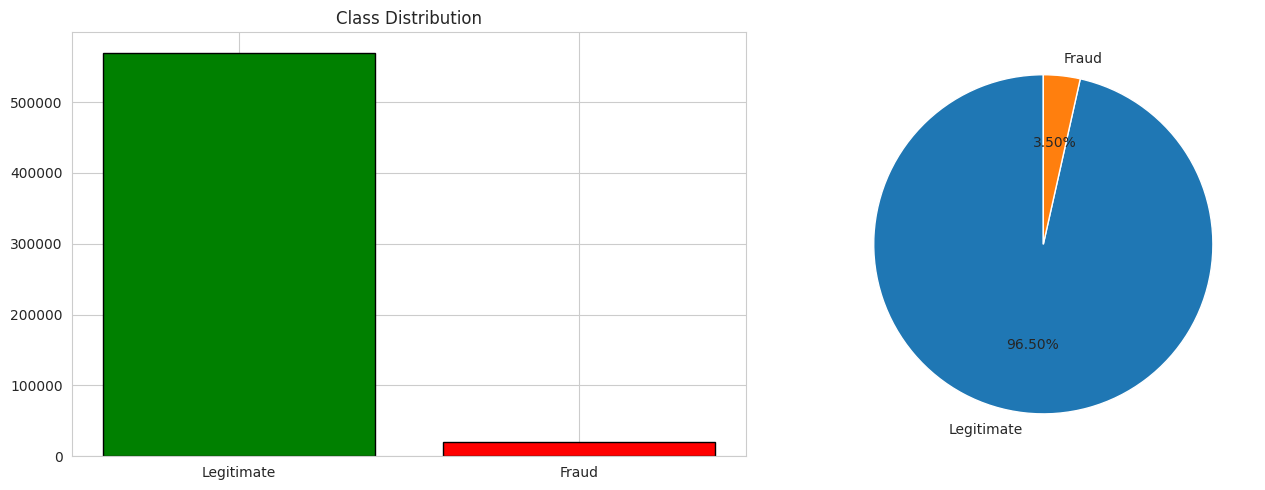

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values,
            color=['green', 'red'], edgecolor='black')
axes[0].set_title("Class Distribution")

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%', startangle=90)


plt.tight_layout()
plt.show()


In [12]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Columns with missing values: {len(missing)}")
missing.head(20)


Columns with missing values: 414


id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
id_26    585377
id_23    585371
id_22    585371
id_27    585371
dist2    552913
D7       551623
id_18    545427
D13      528588
D14      528353
D12      525823
id_04    524216
id_03    524216
D6       517353
id_33    517251
id_10    515614
dtype: int64

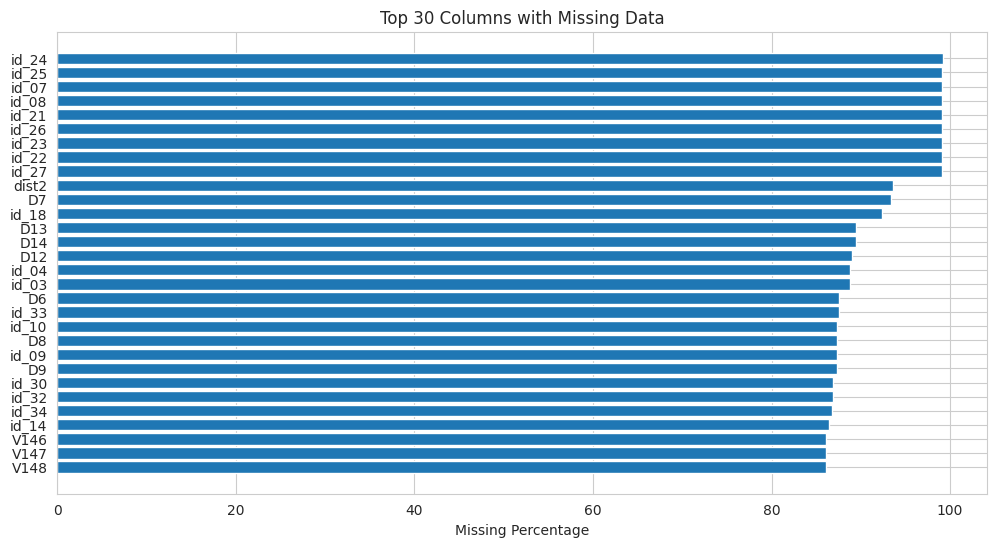

In [13]:
missing_pct = (missing.head(30) / len(df)) * 100

plt.barh(missing_pct.index, missing_pct.values)
plt.xlabel("Missing Percentage")
plt.title("Top 30 Columns with Missing Data")
plt.gca().invert_yaxis()
plt.show()


In [14]:
df.groupby('isFraud')['TransactionAmt'].describe()


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


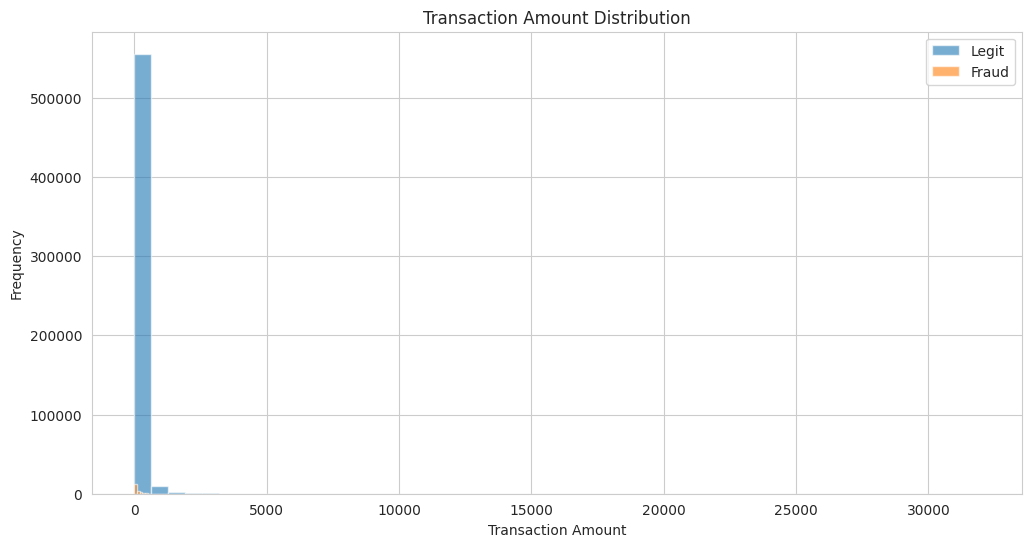

In [15]:
plt.hist(df[df.isFraud==0]['TransactionAmt'], bins=50, alpha=0.6, label='Legit')
plt.hist(df[df.isFraud==1]['TransactionAmt'], bins=50, alpha=0.6, label='Fraud')
plt.legend()
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")
plt.show()


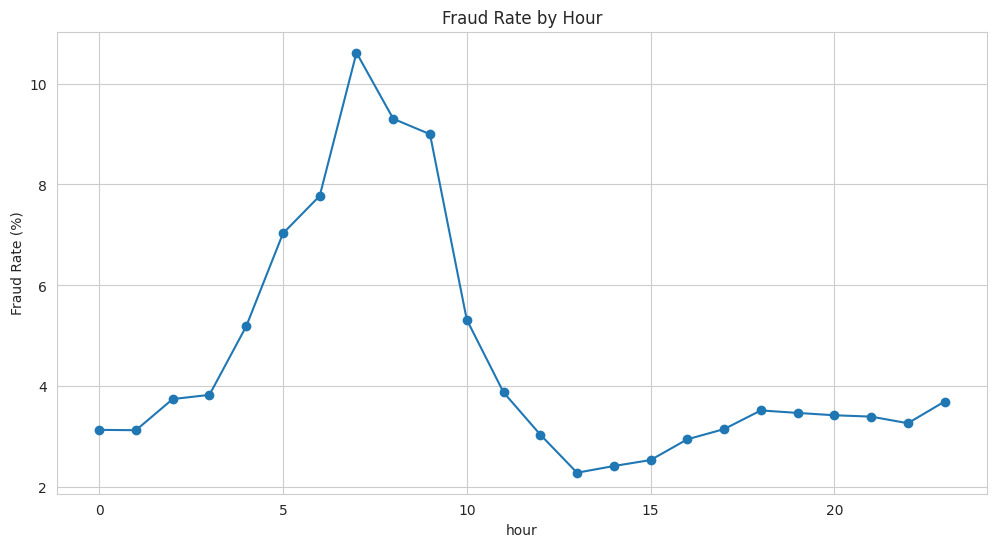

In [16]:
df['hour'] = (df['TransactionDT'] % (24*3600)) / 3600
df['day_of_week'] = ((df['TransactionDT'] / (24*3600)) % 7).astype(int)

hourly_fraud = df.groupby(df['hour'].astype(int))['isFraud'].mean() * 100
hourly_fraud.plot(marker='o', title="Fraud Rate by Hour")
plt.ylabel("Fraud Rate (%)")
plt.show()


In [17]:
numeric_cols = df.select_dtypes(include=np.number)
corr = numeric_cols.corr()['isFraud'].drop('isFraud').sort_values(ascending=False)

corr.head(10)


V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
Name: isFraud, dtype: float64

In [ ]:
df.to_pickle('output/processed_data.pkl')
print("✓ Processed data saved")
